# Week 1 Assignment — Time Series Foundations
### Multi-Agent Forecasting Project

**Name:**  Manthan J
**Date:**  9-06-26

---

This assignment covers the fundamentals of time series analysis that will form the backbone of our multi-agent forecasting system. Complete all sections. Cells marked `# YOUR CODE HERE` require your implementation.

**Topics covered:**
1. Pandas Time Series Basics
2. Visualization with Matplotlib
3. Time Series Components (Trend, Seasonality, Cyclic, Random)
4. Moving Averages
5. Lag Features
6. Putting It All Together

In [2]:
# Run this cell first — installs/imports everything you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Section 1 — Pandas Time Series Basics

Pandas has first-class support for time series data. The key building blocks are:
- `pd.to_datetime()` — parse strings/integers into datetime objects
- `pd.date_range()` — generate a sequence of dates
- `DatetimeIndex` — the index type that unlocks time-aware operations
- `.resample()` — group and aggregate by time frequency
https
**Read:** [Pandas Time Series Documentation](://pandas.pydata.org/docs/user_guide/timeseries.html)

In [3]:


# --- EXAMPLE: Creating a time series in pandas ---

# Generate a daily date range
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Create a simple series with random values
np.random.seed(42)
values = np.random.randn(len(dates)).cumsum() + 100

ts = pd.Series(values, index=dates, name='price')
print("Type of index:", type(ts.index))
print("\nFirst 5 entries:")
print(ts.head())
print("\nSlicing by date string (January only):")
print(ts['2023-01'].head())

Type of index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

First 5 entries:
2023-01-01    100.496714
2023-01-02    100.358450
2023-01-03    101.006138
2023-01-04    102.529168
2023-01-05    102.295015
Freq: D, Name: price, dtype: float64

Slicing by date string (January only):
2023-01-01    100.496714
2023-01-02    100.358450
2023-01-03    101.006138
2023-01-04    102.529168
2023-01-05    102.295015
Freq: D, Name: price, dtype: float64


### Exercise 1.1 — Build Your Own Time Series

Using `pd.date_range`, create a **monthly** time series from `2020-01` to `2024-12` representing simulated monthly sales figures (use `np.random.randint(500, 2000, ...)` for values). Store it in a variable called `sales`.

In [4]:
# YOUR CODE HERE
np.random.seed(0)

# 1. Create a monthly date range from 2020-01 to 2024-12
dates_monthly = pd.date_range(start='2020-01-01', end='2024-12-31', freq='M')

# 2. Create random integer sales values
sales_values = np.random.randint(500,2000,size=len(dates_monthly))

# 3. Create a pd.Series named 'sales'
sales =pd.Series(sales_values,index=dates_monthly,name="Monthly Sales")

print(sales)

2020-01-31    1184
2020-02-29    1059
2020-03-31    1716
2020-04-30    1335
2020-05-31    1263
2020-06-30    1883
2020-07-31    1533
2020-08-31     777
2020-09-30    1099
2020-10-31    1594
2020-11-30    1996
2020-12-31    1100
2021-01-31    1920
2021-02-28     814
2021-03-31    1205
2021-04-30    1051
2021-05-31     587
2021-06-30     674
2021-07-31    1349
2021-08-31    1037
2021-09-30    1345
2021-10-31     572
2021-11-30    1277
2021-12-31     615
2022-01-31    1476
2022-02-28    1255
2022-03-31    1955
2022-04-30     948
2022-05-31    1350
2022-06-30     599
2022-07-31    1701
2022-08-31    1255
2022-09-30    1297
2022-10-31    1159
2022-11-30    1671
2022-12-31    1410
2023-01-31     923
2023-02-28    1812
2023-03-31    1789
2023-04-30    1197
2023-05-31    1139
2023-06-30    1044
2023-07-31    1043
2023-08-31    1214
2023-09-30     744
2023-10-31     651
2023-11-30    1175
2023-12-31    1010
2024-01-31    1983
2024-02-29    1382
2024-03-31    1707
2024-04-30     528
2024-05-31  

C:\Users\manth\AppData\Local\Temp\ipykernel_240\4096252532.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates_monthly = pd.date_range(start='2020-01-01', end='2024-12-31', freq='M')


### Exercise 1.2 — Resampling

Resample `sales` to **quarterly** frequency using `.resample('QE').sum()` and store the result in `sales_quarterly`. Print both the original and resampled series length.

In [5]:
# YOUR CODE HERE
sales_quarterly = sales.resample('QE').sum()

print("Monthly length:", len(sales))
print("Quarterly length:",len(sales_quarterly))
print(sales_quarterly)

Monthly length: 60
Quarterly length: 20
2020-03-31    3959
2020-06-30    4481
2020-09-30    3409
2020-12-31    4690
2021-03-31    3939
2021-06-30    2312
2021-09-30    3731
2021-12-31    2464
2022-03-31    4686
2022-06-30    2897
2022-09-30    4253
2022-12-31    4240
2023-03-31    4524
2023-06-30    3380
2023-09-30    3001
2023-12-31    2836
2024-03-31    5072
2024-06-30    2458
2024-09-30    3461
2024-12-31    2496
Freq: QE-DEC, Name: Monthly Sales, dtype: int32


---
## Section 2 — Visualization with Matplotlib

Good time series plots communicate trends and patterns clearly. Key practices:
- Always label axes with units and time period
- Use `fig, ax = plt.subplots()` for fine-grained control
- Format the x-axis with `mdates` for readable date ticks
- Use `tight_layout()` to prevent label clipping

**Read:** [Matplotlib Time Series Plotting](https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html)

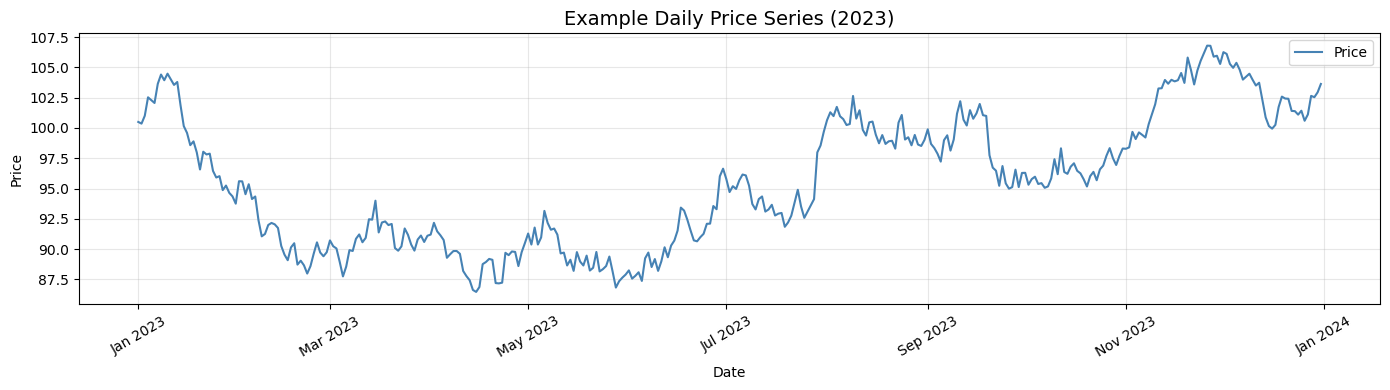

In [6]:
# --- EXAMPLE: Proper time series plot ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.5, label='Price')
ax.set_title('Example Daily Price Series (2023)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 2.1 — Plot Your Sales Series

Plot your `sales` series (monthly) and `sales_quarterly` on the **same figure** with two subplots (one above the other). Include titles, axis labels, and formatted x-axis ticks.

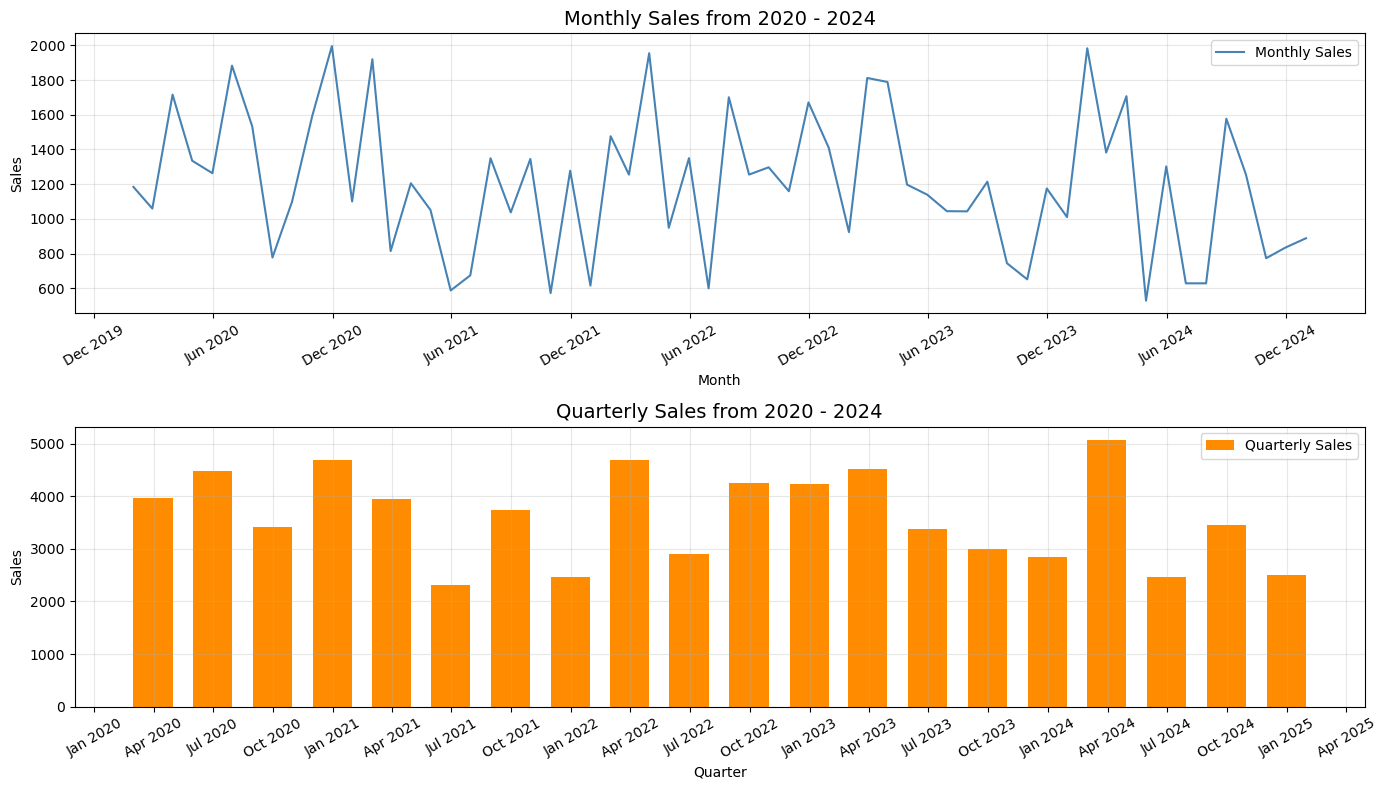

In [7]:
# YOUR CODE HERE
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Top subplot: monthly sales
ax1.plot(sales.index, sales.values, color='steelblue', linewidth=1.5, label='Monthly Sales')
ax1.set_title('Monthly Sales from 2020 - 2024', fontsize=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.tick_params(axis='x', rotation=30)
ax1.legend()


# Bottom subplot: quarterly sales (use bar chart — ax2.bar(...))
ax2.bar(sales_quarterly.index, sales_quarterly.values, color='darkorange', width=60, label='Quarterly Sales')
ax2.set_title('Quarterly Sales from 2020 - 2024', fontsize=14)
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Sales')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

plt.tight_layout()
plt.show()

---
## Section 3 — Time Series Components

Any time series can be decomposed into four components:

| Component | Description | Example |
|-----------|-------------|---------|
| **Trend** | Long-run direction (up/down/flat) | Revenue growing year-over-year |
| **Seasonality** | Regular, repeating patterns at fixed intervals | Higher retail sales every December |
| **Cyclic variation** | Wave-like fluctuations over non-fixed periods | Business/economic cycles |
| **Random / Residual** | Irregular, unpredictable noise | One-off supply chain disruption |

The **additive model** assumes: `y(t) = Trend + Seasonality + Cyclic + Random`  
The **multiplicative model** assumes: `y(t) = Trend × Seasonality × Cyclic × Random`  
Use multiplicative when variance grows with the level of the series.

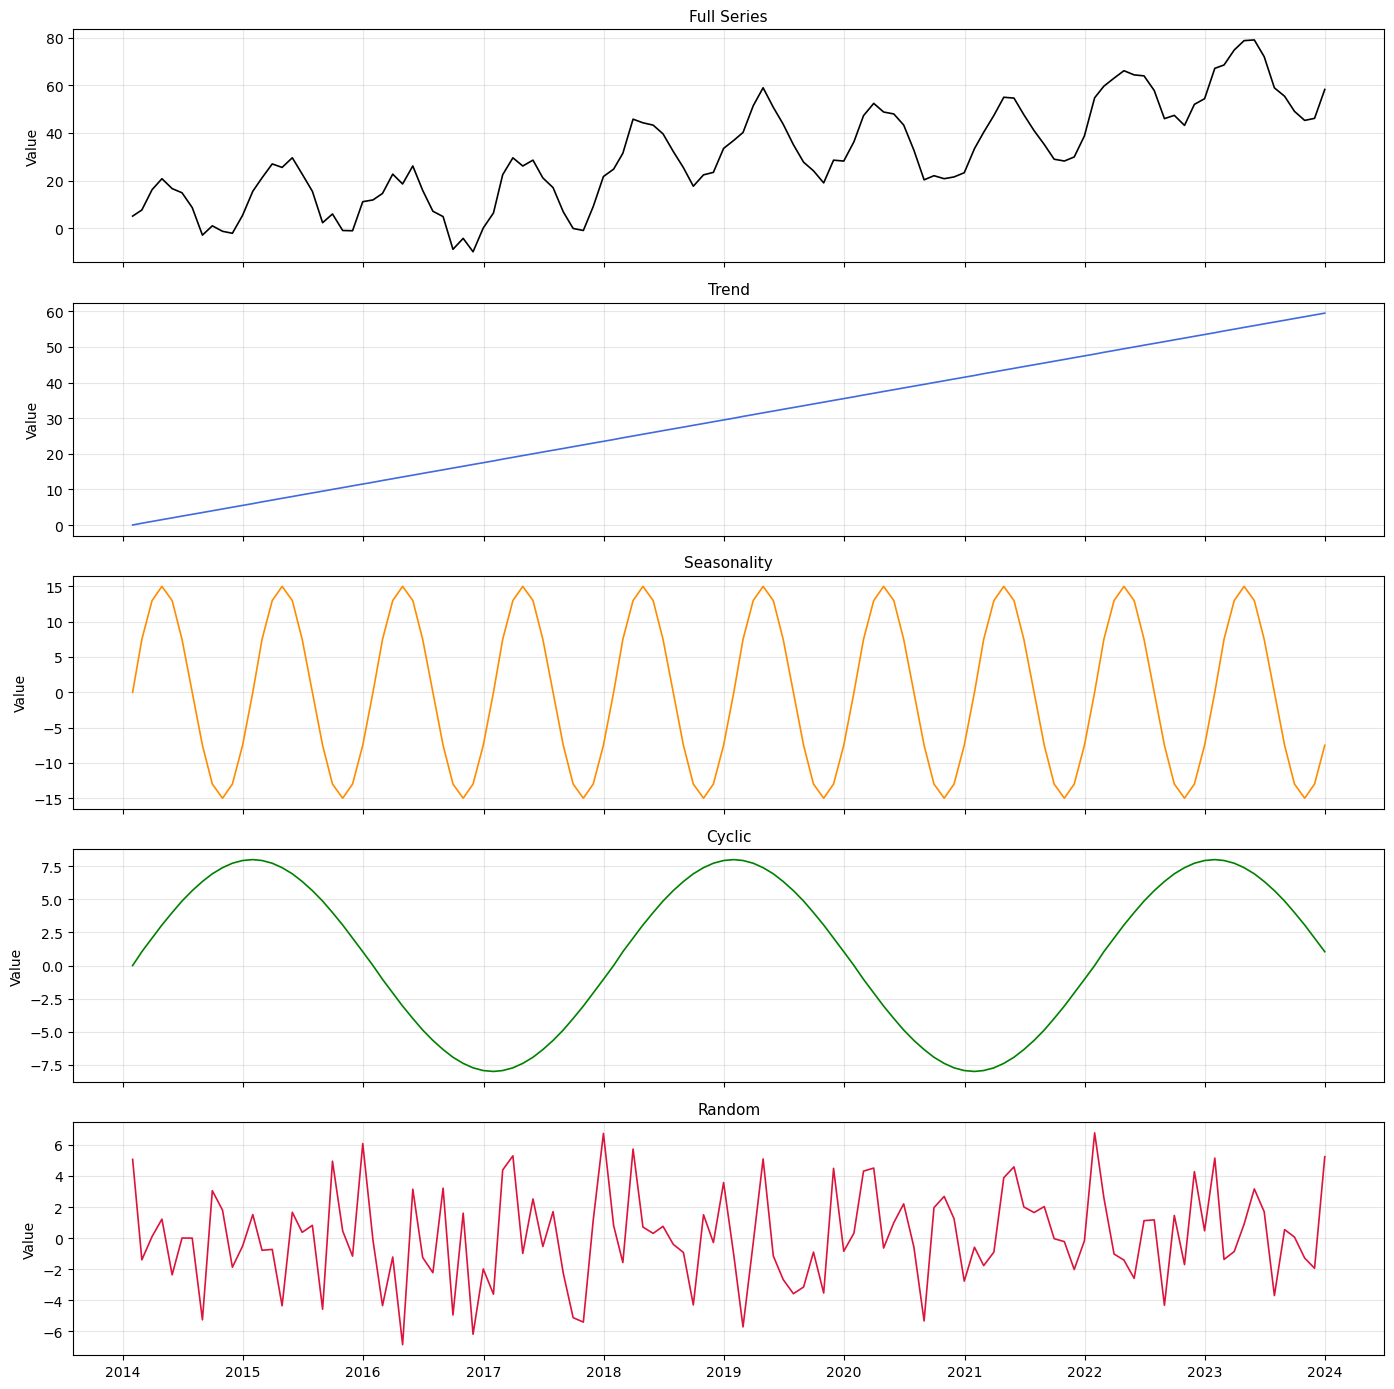

In [8]:
# --- EXAMPLE: Synthetic series with known components ---

np.random.seed(7)
t = np.arange(120)  # 10 years of monthly data
dates_ex = pd.date_range('2014-01', periods=120, freq='ME')

trend      = 0.5 * t                              # upward linear trend
seasonality = 15 * np.sin(2 * np.pi * t / 12)    # annual seasonal cycle
cyclic     = 8 * np.sin(2 * np.pi * t / 48)      # ~4-year business cycle
random     = np.random.normal(0, 3, 120)          # random noise

y = trend + seasonality + cyclic + random
series_ex = pd.Series(y, index=dates_ex, name='synthetic')

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ax, data, title, color in zip(
    axes,
    [y, trend, seasonality, cyclic, random],
    ['Full Series', 'Trend', 'Seasonality', 'Cyclic', 'Random'],
    ['black', 'royalblue', 'darkorange', 'green', 'crimson']
):
    ax.plot(dates_ex, data, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

### Exercise 3.1 — Seasonal Decomposition

Use `seasonal_decompose` from `statsmodels` to decompose `series_ex`. Set `model='additive'` and `period=12`. Plot all four components using the result's `.plot()` method.

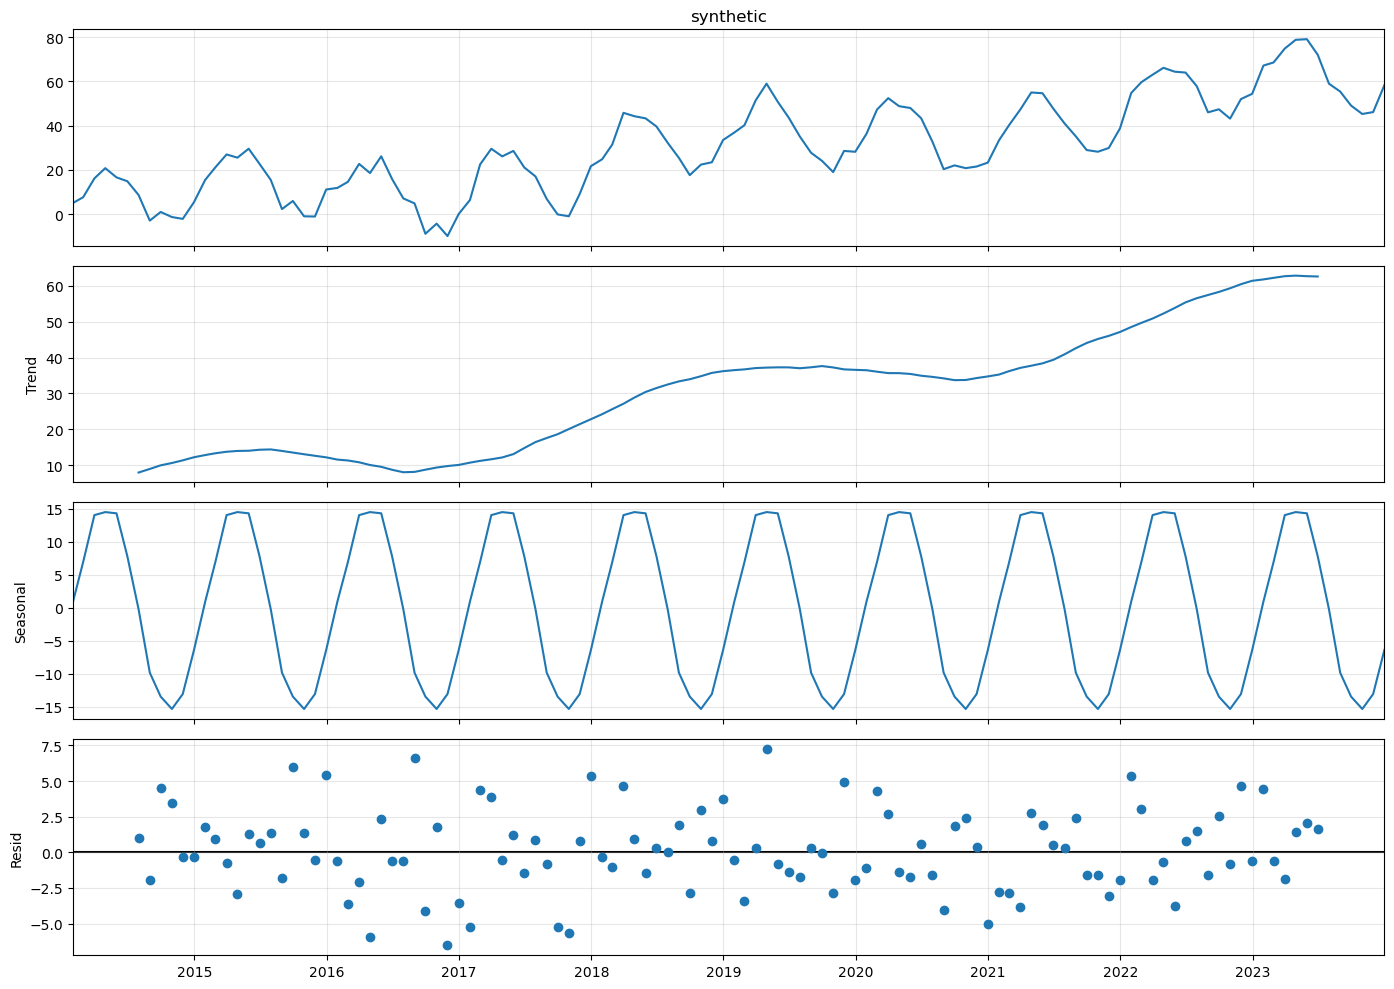

In [9]:
# YOUR CODE HERE
decomposition = seasonal_decompose(series_ex,model="additive",period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

### Exercise 3.2 — Short Answer

Answer the following in the markdown cell below:

1. What does the **residual** component from the decomposition tell you? What would a large residual suggest about a data point?
2. When would you prefer a **multiplicative** decomposition over an additive one? Give a real-world example.

**Your answers here:**

1. It represents the random fluctuationsin the data that are left over after the underlying Trend and Seasonal patterns have been mathematically subtracted (or divided) out.If a specific data point has a very large residual, it suggests an anomaly or outlier. It means that something highly unusual and unpredictable happened at that moment in time that cannot be explained by the normal seasonal cycle or the overall trend.

2. The multiplicative decomposition is preferred when the amplitude of the seasonal swings grows or shrinks proportionally with the overall trend.
Eg :-An Air Passengers dataset  is a classic example. In the early years(when the baseline trend was around 100 passengers), the seasonal difference between winter and summer is small—maybe 20 extra passengers. Ten years later, when the baseline trend reached 400 passengers, the summer spike is suddenly over 100 extra passengers. Because the size of the seasonal swing multiplied as the industry grew, a multiplicative model is required to accurately capture the pattern.

---
## Section 4 — Moving Averages

A **moving average** (rolling mean) smooths out short-term fluctuations to reveal underlying trends. In pandas:

```python
series.rolling(window=7).mean()   # 7-period simple moving average
series.ewm(span=7).mean()         # exponentially weighted moving average
```

Key parameters:
- `window` — number of periods to average
- `min_periods` — minimum observations needed (default = window)
- `center=True` — center the window instead of trailing

**Read:** [Moving Averages in Pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)

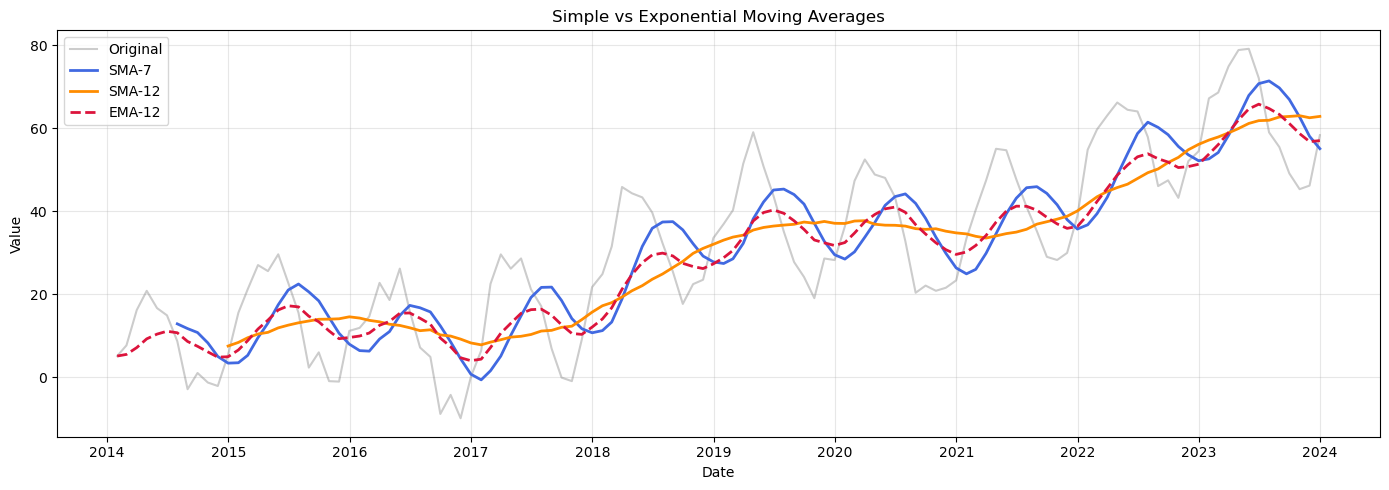

In [10]:
# --- EXAMPLE: SMA vs EMA ---

sma_7  = series_ex.rolling(window=7).mean()
sma_12 = series_ex.rolling(window=12).mean()
ema_12 = series_ex.ewm(span=12, adjust=False).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(series_ex.index, series_ex, alpha=0.4, color='gray', label='Original')
ax.plot(sma_7.index,  sma_7,  color='royalblue',   linewidth=2, label='SMA-7')
ax.plot(sma_12.index, sma_12, color='darkorange',   linewidth=2, label='SMA-12')
ax.plot(ema_12.index, ema_12, color='crimson',      linewidth=2, label='EMA-12', linestyle='--')
ax.set_title('Simple vs Exponential Moving Averages')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 4.1 — Rolling Statistics on Sales

On your `sales` series, compute:
- A **3-month SMA**
- A **12-month SMA** (annual trend)
- A **rolling standard deviation** with window=6

Plot the original series alongside both SMAs on one axis, and the rolling std on a second axis below.

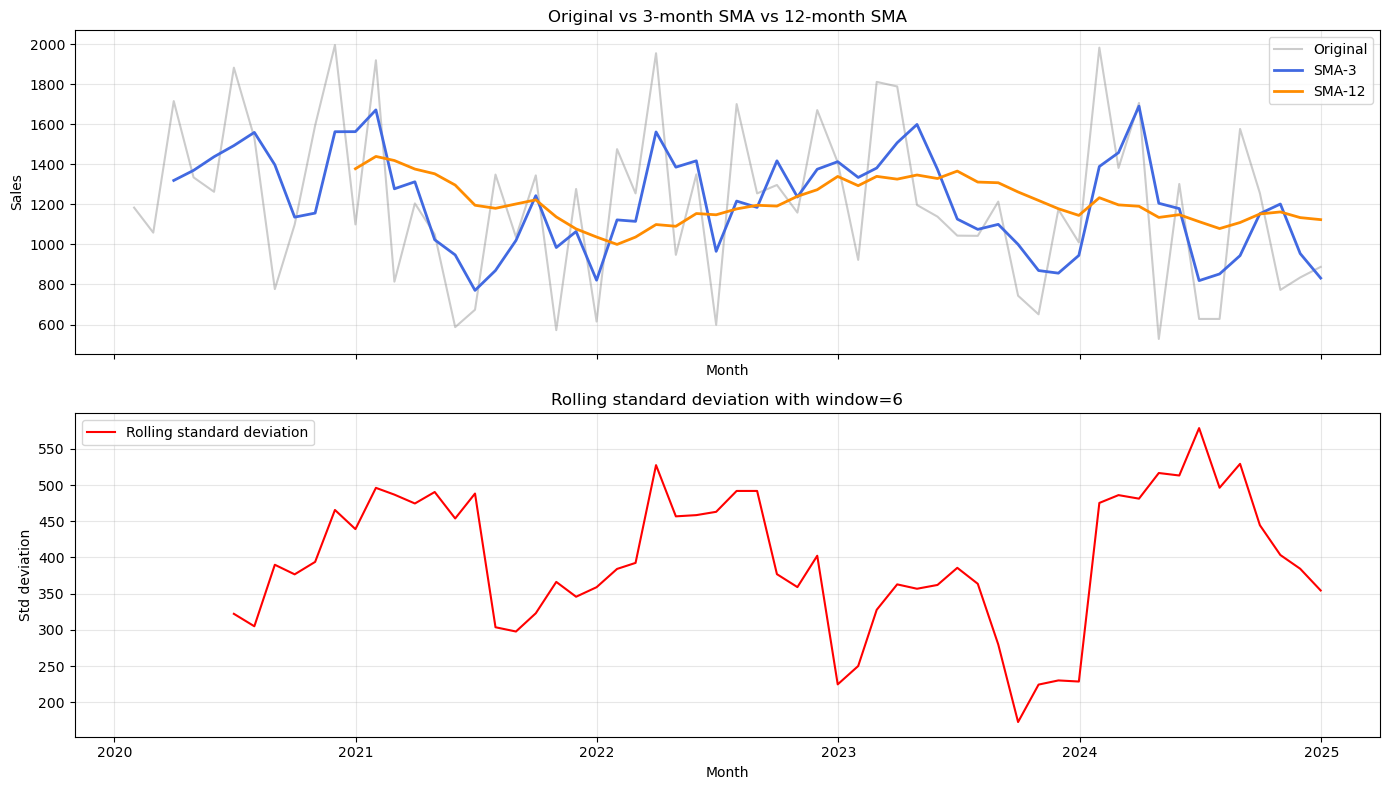

In [11]:
# YOUR CODE HERE
sma_3  = sales.rolling(window=3).mean()
Sma_12 = sales.rolling(window=12).mean()
roll_std  = sales.rolling(window=6).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: original + SMAs
ax1.plot(sales.index, sales, alpha=0.4, color='gray', label='Original')
ax1.plot(sma_3.index,  sma_3,  color='royalblue',   linewidth=2, label='SMA-3')
ax1.plot(Sma_12.index, Sma_12, color='darkorange',   linewidth=2, label='SMA-12')
ax1.set_title('Original vs 3-month SMA vs 12-month SMA')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales')
ax1.legend()

# Bottom: rolling std
ax2.plot(roll_std.index, roll_std, color='red', label='Rolling standard deviation')
ax2.set_title('Rolling standard deviation with window=6')
ax2.set_xlabel('Month')
ax2.set_ylabel('Std deviation')
ax2.legend()

plt.tight_layout()
plt.show()

### Exercise 4.2 — Short Answer

1. Why does the SMA produce `NaN` values at the start of the series? How could `min_periods` help?
2. What is the main advantage of EMA over SMA for forecasting recent trends?

**Your answers here:**

1. A Simple Moving Average (SMA) requires a full "window" of historical data to calculate a single value. For example, if you set window=12 for a 12-month SMA, pandas cannot calculate an average for the very first month (Index 0) because there are no 11 prior months to average it with. It will output NaN for the first 11 rows, and only produce its first real number on the 12th row.
y default, min_periods is equal to your window size. If you change it to min_periods=1, you are telling pandas: "If you don't have the full 12 months, just calculate the average using whatever data you DO have." This allows the function to output a 1-month average for row 1, a 2-month average for row 2, and so on, completely eliminating the starting NaNs.

2. The main advantage of an Exponential Moving Average (EMA) is that it is much more responsive to recent changes.

An SMA assigns the exact same mathematical weight to every data point in the window. (In a 12-month SMA, what happened 11 months ago impacts the average just as heavily as what happened yesterday).

An EMA assigns exponentially decreasing weights to older data. The most recent data gets the highest weight, while the oldest data in the window gets the lowest weight. This means if a sudden shift, shock, or trend reversal happens in your dataset, an EMA will "catch" and reflect that new trend almost immediately, whereas an SMA will lag significantly behind.

---
## Section 5 — Lag Features

A **lag feature** is the value of a series at a previous time step. They are the most important input features for time series forecasting models because they encode the *memory* of the series.

```python
df['lag_1'] = df['value'].shift(1)   # value from 1 step ago
df['lag_7'] = df['value'].shift(7)   # value from 7 steps ago
```

**Why they matter:** A model predicting tomorrow's value benefits from knowing yesterday's value (`lag_1`), last week's value (`lag_7`), and last year's same-week value (`lag_52` for weekly data). In a multi-agent forecasting system, different agents may specialize in different lag horizons.

**Read:** [Lag Features Explained](https://machinelearningmastery.com/basic-feature-engineering-time-series-data-python/)

In [12]:
# --- EXAMPLE: Building a lag feature DataFrame ---

df_lags = pd.DataFrame({'value': series_ex})

for lag in [1, 2, 3, 6, 12]:
    df_lags[f'lag_{lag}'] = df_lags['value'].shift(lag)

print("Shape:", df_lags.shape)
print("\nFirst 15 rows (notice NaN at start):")
print(df_lags.head(15).round(2))

Shape: (120, 6)

First 15 rows (notice NaN at start):
            value  lag_1  lag_2  lag_3  lag_6  lag_12
2014-01-31   5.07    NaN    NaN    NaN    NaN     NaN
2014-02-28   7.65   5.07    NaN    NaN    NaN     NaN
2014-03-31  16.16   7.65   5.07    NaN    NaN     NaN
2014-04-30  20.78  16.16   7.65   5.07    NaN     NaN
2014-05-31  16.62  20.78  16.16   7.65    NaN     NaN
2014-06-30  14.88  16.62  20.78  16.16    NaN     NaN
2014-07-31   8.65  14.88  16.62  20.78   5.07     NaN
2014-08-31  -2.92   8.65  14.88  16.62   7.65     NaN
2014-09-30   0.99  -2.92   8.65  14.88  16.16     NaN
2014-10-31  -1.31   0.99  -2.92   8.65  20.78     NaN
2014-11-30  -2.14  -1.31   0.99  -2.92  16.62     NaN
2014-12-31   5.42  -2.14  -1.31   0.99  14.88     NaN
2015-01-31  15.52   5.42  -2.14  -1.31   8.65    5.07
2015-02-28  21.15  15.52   5.42  -2.14  -2.92    7.65
2015-03-31  26.99  21.15  15.52   5.42   0.99   16.16


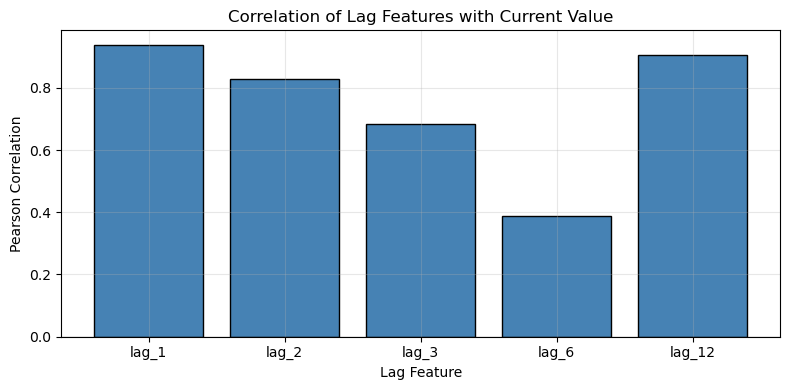

In [13]:
# --- EXAMPLE: Lag correlation plot ---
# How correlated is each lag with the current value?

df_clean = df_lags.dropna()
correlations = {col: df_clean['value'].corr(df_clean[col]) 
                for col in df_clean.columns if col != 'value'}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(correlations.keys(), correlations.values(), color='steelblue', edgecolor='black')
ax.set_title('Correlation of Lag Features with Current Value')
ax.set_xlabel('Lag Feature')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Exercise 5.1 — Lag Features for Sales

Build a DataFrame from your `sales` series with lag features for lags: 1, 2, 3, 6, and 12 months. Then:
1. Drop rows with `NaN` values
2. Compute and print a **correlation matrix** using `.corr()`
3. Plot the correlation of each lag feature with the target (`sales`) as a bar chart

        sales  lag_1  lag_2  lag_3  lag_6  lag_12
sales   1.000 -0.066  0.264 -0.210  0.151   0.150
lag_1  -0.066  1.000 -0.083  0.247 -0.260  -0.238
lag_2   0.264 -0.083  1.000 -0.058  0.077   0.066
lag_3  -0.210  0.247 -0.058  1.000 -0.243  -0.122
lag_6   0.151 -0.260  0.077 -0.243  1.000   0.151
lag_12  0.150 -0.238  0.066 -0.122  0.151   1.000


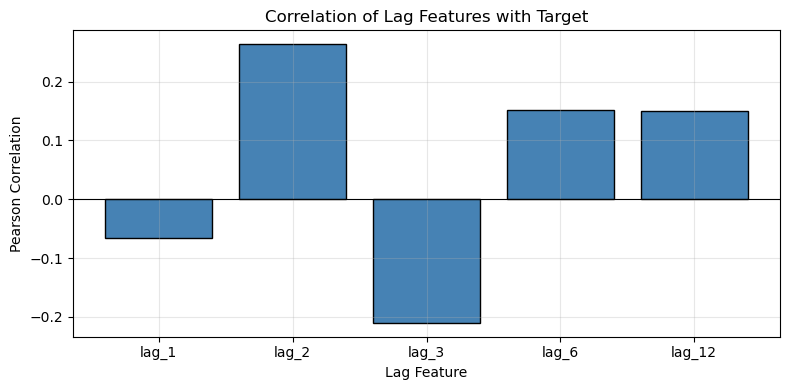

In [14]:
# YOUR CODE HERE
df_sales = pd.DataFrame({'sales': sales})

# 1. Add lag features
for lag in [1, 2, 3, 6, 12]:
    df_sales[f'lag_{lag}'] = df_sales['sales'].shift(lag)

# 2. Drop NaNs
df_sales = df_sales.dropna()

# 3. Correlation matrix
print(df_sales.corr().round(3))

# 4. Bar chart of lag correlations with target
correl = {col: df_sales['sales'].corr(df_sales[col]) 
                for col in df_sales.columns if col != 'sales'}
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(correl.keys(), correl.values(), color='steelblue', edgecolor='black')
ax.set_title('Correlation of Lag Features with Target')
ax.set_xlabel('Lag Feature')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


### Exercise 5.2 — Short Answer

1. In the context of multi-agent forecasting: if one agent uses `lag_1` and `lag_2` while another uses `lag_12`, what different *aspects* of the series is each agent likely capturing?
2. What problem arises if you use a lag feature without dropping `NaN` rows before training a model?

**Your answers here:**

1. In a multi-agent or ensemble forecasting setup, different lags specialize in capturing completely different behaviors:

The lag_1 and lag_2 Agent: This agent specializes in recent momentum and short-term trends. It looks at what just happened in the immediate past to establish a current baseline. If a sudden shock or rapid trend starts (like a viral trend causing a massive spike in sales), these short lags will catch it immediately and adjust the forecast upward for the next step.

The lag_12 Agent: this agent specializes entirely in annual seasonality. It doesn't care about recent momentum; it only cares about what happened at this exact time last year. It allows the model to anticipate predictable, repeating cycles (like holiday shopping in December or summer travel in July) regardless of what happened last month.

2. Most standard machine learning models will crash and throw an error if there is a NaN value in the dataset


---
## Section 6 — Putting It All Together

This final section combines everything: load a real-world style dataset, visualize it, decompose it, and engineer features from it.

We'll use the **Air Passengers** dataset — monthly international airline passengers from 1949–1960. It's a classic benchmark that exhibits clear trend, seasonality, and multiplicative growth.

In [15]:
# Load the Air Passengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
air = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
air.columns = ['passengers']
air.index.freq = 'MS'  # month start
print(air.head())
print("\nShape:", air.shape)

            passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Shape: (144, 1)


### Exercise 6.1 — Full EDA

Perform a complete exploratory analysis of the `air` dataset:

1. Plot the raw series
2. Overlay a 12-month SMA
3. Run a **multiplicative** seasonal decomposition (`model='multiplicative'`, `period=12`) and plot it
4. Build lag features for lags 1, 12 (same month last year), and 24
5. Plot the lag-12 correlation scatter plot: `air['passengers']` (y-axis) vs `lag_12` (x-axis). What does this tell you?

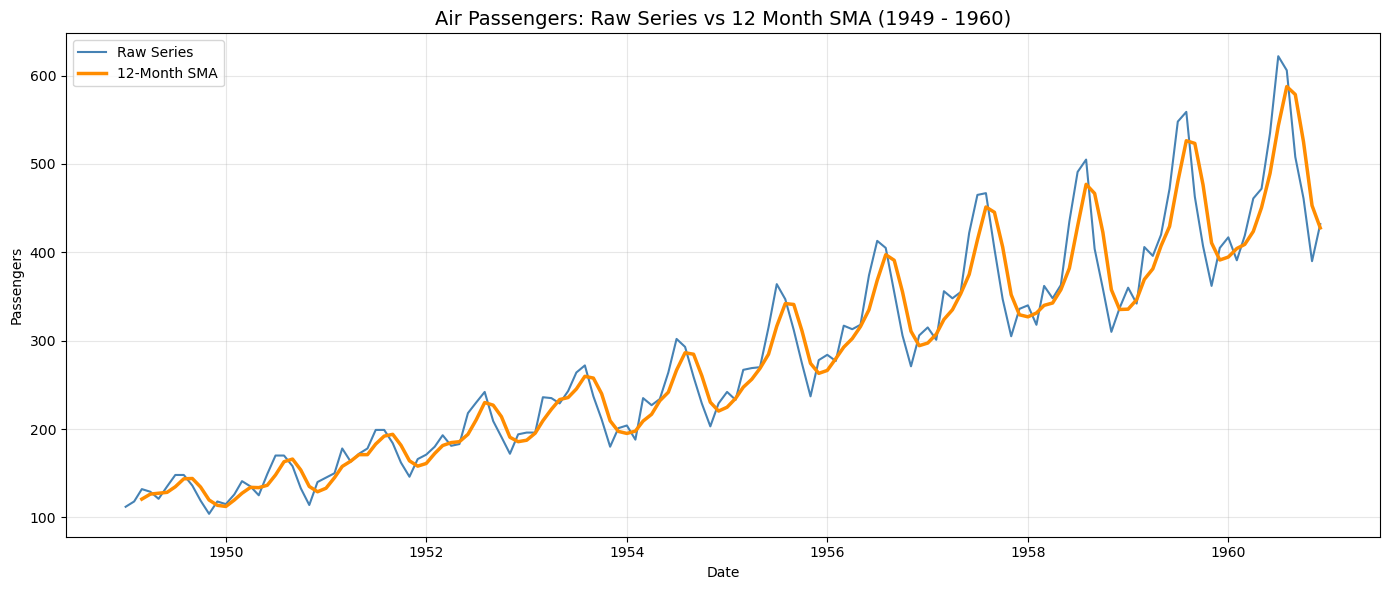

In [16]:
# Part 1 & 2: Raw series + 12-month SMA
# YOUR CODE HERE
sma_12  = air['passengers'].rolling(window=3).mean()
fig,ax = plt.subplots( figsize=(14, 6))
ax.plot(air.index, air['passengers'], color='steelblue', label='Raw Series')
ax.plot(sma_12.index,  sma_12,  color='darkorange',   linewidth=2.5, label='12-Month SMA')
ax.set_title('Air Passengers: Raw Series vs 12 Month SMA (1949 - 1960)',fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()


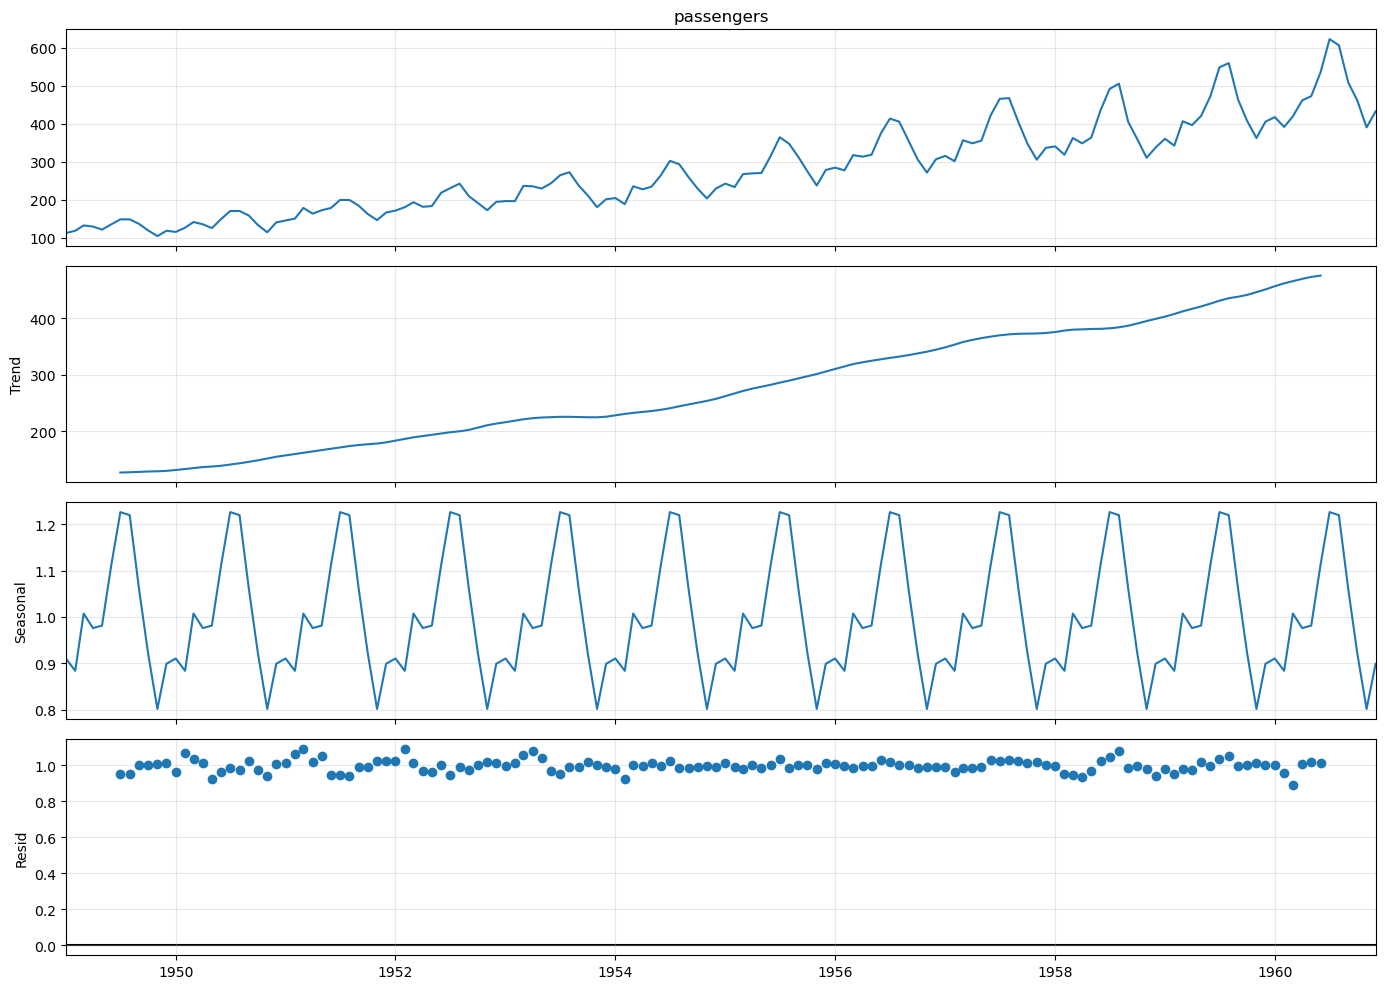

In [17]:
# Part 3: Multiplicative decomposition
# YOUR CODE HERE
decomposition=seasonal_decompose(air['passengers'],model='multiplicative',period=12)
fig=decomposition.plot()
fig.set_size_inches(14,10)
plt.tight_layout()
plt.show()

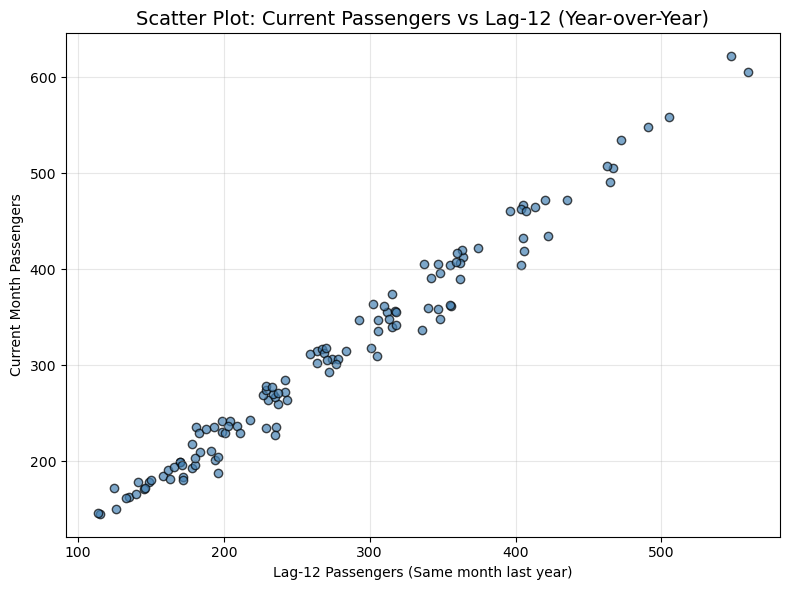

In [18]:
# Part 4 & 5: Lag features + scatter plot
# YOUR CODE HERE
air_features=air.copy()
for lag in [1, 12,24]:
    air_features[f'lag_{lag}'] = air_features['passengers'].shift(lag)
plot_data=air_features.dropna()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_data['lag_12'], plot_data['passengers'], color='steelblue', alpha=0.7, edgecolor='black')

ax.set_title('Scatter Plot: Current Passengers vs Lag-12 (Year-over-Year)', fontsize=14)
ax.set_xlabel('Lag-12 Passengers (Same month last year)')
ax.set_ylabel('Current Month Passengers')

plt.tight_layout()
plt.show()

# This plot tells us that there is a massive positive correlation between lag_12 and the current month because the groupng of points is linear.
# The points are slightly above the y=x line which means that year by year the no of passengers travelling in the same month increases.


### Exercise 6.2 — Reflection

Answer in 3–5 sentences: Based on your analysis of the Air Passengers dataset, which components (trend, seasonality, cyclic, random) are most prominent? Which lag features would you prioritize as inputs to a forecasting model and why? How does this connect to the idea of having specialized agents in a multi-agent forecasting system?

**Your answer here:**

Based on the analysis, the Air Passengers dataset is heavily dominated by a persistent upward trend and a highly predictable, multiplicative annual seasonality. Consequently, lag_12 is the highest priority feature for predicting the magnitude of recurring yearly passenger peaks, while lag_1 remains essential for anchoring the model to the most recent, short-term momentum. In a multi-agent forecasting system, this directly informs the architecture: you can deploy one specialized agent focused purely on anticipating macro-seasonal cycles (using historical year-over-year lags) and another dedicated to reacting to immediate baseline shifts (using short-term lags), allowing a master model to intelligently combine their distinct perspectives.

---
## Bonus Challenge ⭐

Combine moving averages and lag features into a single feature-engineered DataFrame for the Air Passengers dataset with the following columns:
- `passengers` (target)
- `lag_1`, `lag_12`
- `sma_3`, `sma_12`
- `rolling_std_6`
- `month` (integer 1–12, extracted from the index) — this encodes seasonality

Drop NaN rows and print the final shape and first 5 rows. This DataFrame is what you'd feed into a forecasting model in Week 2.

In [19]:
# BONUS — YOUR CODE HERE
df_model = pd.DataFrame({'passengers': air['passengers']})
df_model['lag_1'] = df_model['passengers'].shift(1)
df_model['lag_12'] = df_model['passengers'].shift(12)
df_model['sma_3'] = df_model['passengers'].rolling(window=3).mean()
df_model['sma_12'] = df_model['passengers'].rolling(window=12).mean()
df_model['rolling_std_6'] = df_model['passengers'].rolling(window=6).std()
df_model['month'] = df_model.index.month
df_final = df_model.dropna()
print("Final Shape:", df_final.shape)
print("\nFirst 5 rows:")
print(df_final.head())

Final Shape: (132, 7)

First 5 rows:
            passengers  lag_1  lag_12       sma_3      sma_12  rolling_std_6  \
Month                                                                          
1950-01-01         115  118.0   112.0  112.333333  126.916667      15.870308   
1950-02-01         126  115.0   118.0  119.666667  127.583333      10.745542   
1950-03-01         141  126.0   132.0  127.333333  128.333333      12.340989   
1950-04-01         135  141.0   129.0  134.000000  128.833333      13.614943   
1950-05-01         125  135.0   121.0  133.666667  129.166667       9.892758   

            month  
Month              
1950-01-01      1  
1950-02-01      2  
1950-03-01      3  
1950-04-01      4  
1950-05-01      5  


---
## Submission Checklist

Before submitting, make sure:
- [ ] All `# YOUR CODE HERE` cells are filled in and run without errors
- [ ] All short-answer cells are filled in
- [ ] All plots have titles, axis labels, and legends
- [ ] The notebook runs top-to-bottom with **Kernel → Restart & Run All**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week1_Assignment_YourName.ipynb`